In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import scipy.spatial as spatial
import scipy.cluster as clstr
from collections import defaultdict
import operator
from pathlib import Path

In [2]:
project_dir = Path.cwd().parent
print(project_dir)

c:\Users\feran\Projects\chessify


In [3]:
img = cv2.imread(project_dir / "notebooks" / "game_opera" / "game_opera0.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

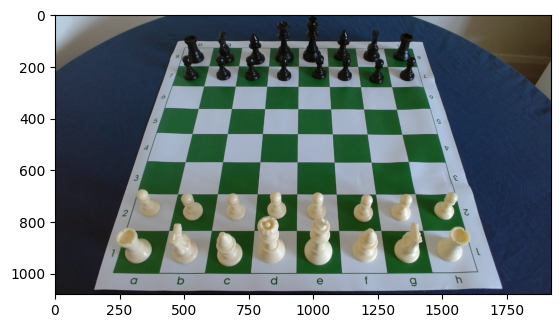

In [4]:
plt.imshow(img)

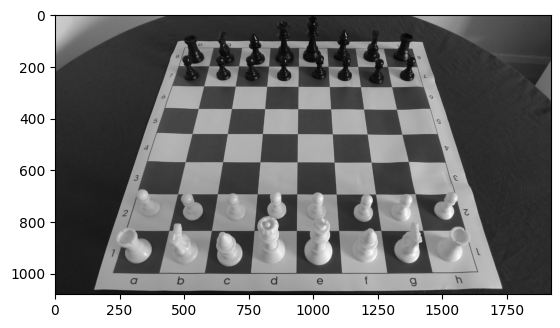

In [5]:
grey = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
plt.imshow(grey, cmap = "grey")

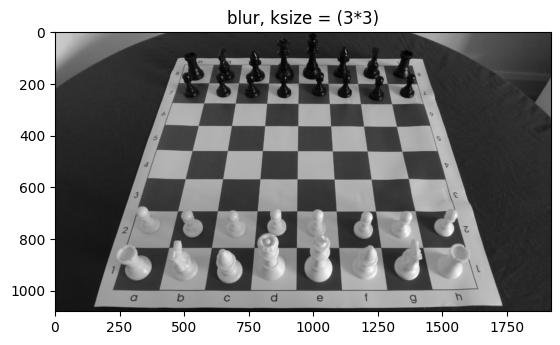

In [6]:
blur = cv2.blur(grey, (3, 3))
plt.title("blur, ksize = (3*3)")
plt.imshow(blur, cmap = "grey")

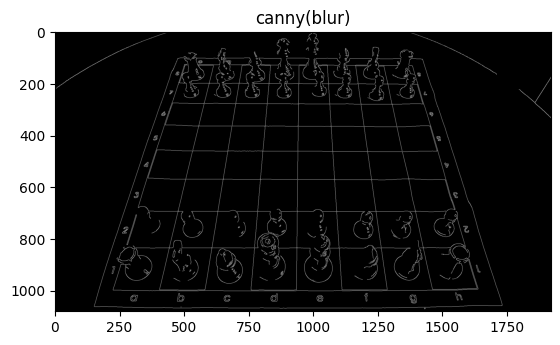

In [7]:
v = np.median(blur)
sigma = 0.33
l = int(max(0, (1.0 - sigma) * v))
u = int(min(255, (1.0 + sigma) * v))
canny = cv2.Canny(blur, l, u)
plt.title("canny(blur)")
plt.imshow(canny, cmap = "grey")

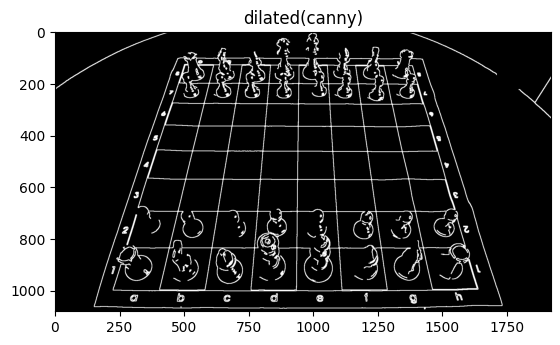

In [8]:
kernel = np.ones((3, 3), np.uint8)
dilated = cv2.dilate(canny, kernel, iterations = 1)
plt.title("dilated(canny)")
plt.imshow(dilated, cmap = "grey")

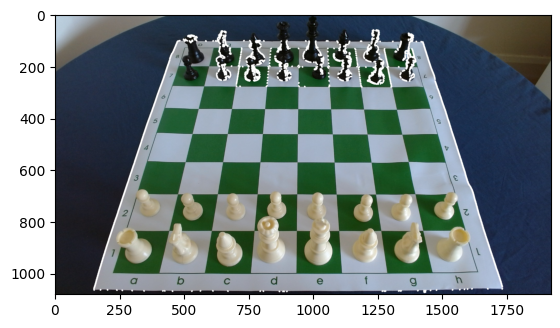

In [9]:
cnts, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest_contour = max(cnts, key=cv2.contourArea)
base = img.copy()
cv2.drawContours(base, largest_contour, -1, (255, 255, 255), 5)
plt.imshow(base, cmap = 'grey')   

In [10]:
def find_corners(points):
    #max x + y
    bottom_right, _ = max(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x + y
    top_left, _ = min(enumerate([point[0] + point[1] for point in points]), key=operator.itemgetter(1))
    #min x - y
    bottom_left, _ = min(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    #max x - y
    top_right, _ = max(enumerate([point[0] - point[1] for point in points]), key=operator.itemgetter(1))
    return [points[top_left], points[top_right], points[bottom_left], points[bottom_right]]

board_corners = find_corners(largest_contour[:, 0, :])
board_corners

[array([474, 104], dtype=int32),
 array([1421,  108], dtype=int32),
 array([ 150, 1063], dtype=int32),
 array([1727, 1060], dtype=int32)]

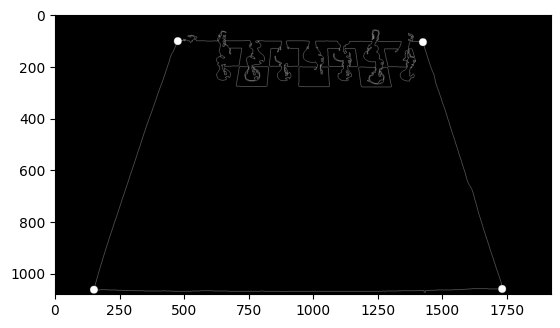

In [11]:
h, w, l = img.shape
corners_image = np.zeros((h, w, 3), np.uint8)
cv2.drawContours(corners_image, [largest_contour], -1, (255, 255, 255), 1)

cv2.circle(corners_image, board_corners[0], 15, (255, 255, 255), -1)  # red for top-left
cv2.circle(corners_image, board_corners[1], 15, (255, 255, 255), -1)  # green for top-right
cv2.circle(corners_image, board_corners[2], 15, (255, 255,255), -1)  # blue for bottom-left
cv2.circle(corners_image, board_corners[3], 15, (255, 255, 255), -1)  # yellow for bottom-right


board_corners = np.asarray(board_corners, dtype = "float32")
plt.imshow(corners_image, cmap="gray")

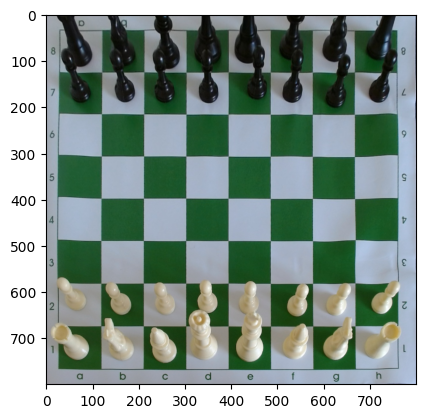

In [12]:
height, width = 800, 800
dimensions = np.float32([[0, 0],[width, 0], [0, height],[width, height]])
M = cv2.getPerspectiveTransform(board_corners, dimensions)
M_inv = cv2.invert(M)[1]
board = cv2.warpPerspective(img, M, (width, height))
plt.imshow(board)

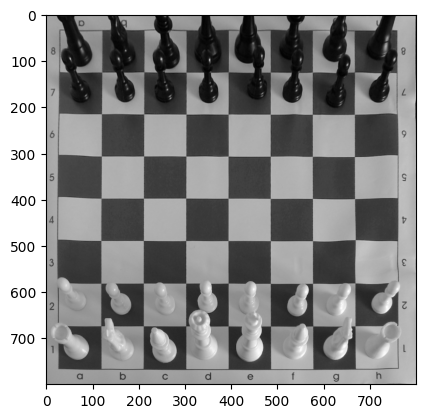

In [13]:
base = board.copy()
grey = cv2.cvtColor(board, cv2.COLOR_RGB2GRAY)
plt.imshow(grey, cmap = "gray")

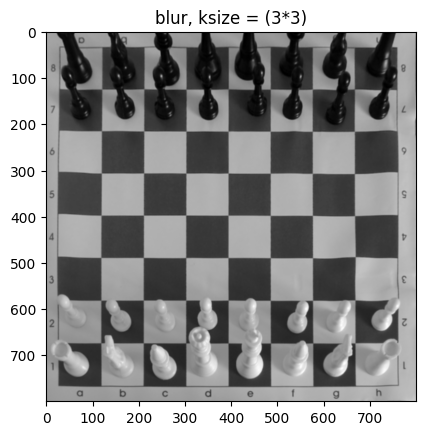

In [14]:
blur = cv2.blur(grey, (3, 3))
plt.title("blur, ksize = (3*3)")
plt.imshow(blur, cmap = "grey")

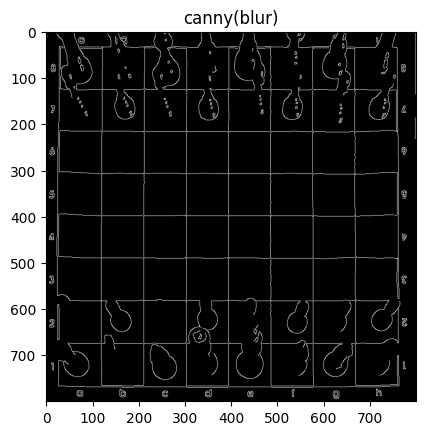

In [15]:
v = np.median(blur)
l = int(max(0, (1.0 - sigma) * v))
u = int(min(255, (1.0 + sigma) * v))
canny = cv2.Canny(blur, l, u)
plt.title("canny(blur)")
plt.imshow(canny, cmap = "grey")

In [16]:
def drawHough(lines, image):
    for line in lines:
        rho = line[0][0]
        theta = line[0][1]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*rho
        y0 = b*rho
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))
        cv2.line(image, (x1, y1), (x2, y2), (0, 0, 255), 2)    

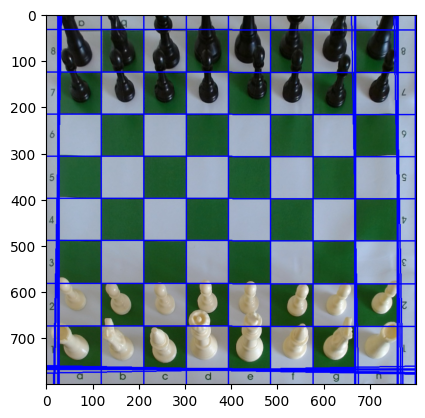

In [17]:
base = board.copy()
lines = cv2.HoughLines(canny, 1, np.pi/180, 150)
drawHough(lines, base)
plt.imshow(base)

In [18]:
lines = np.reshape(lines, (-1, 2))
h = []
v = []
for rho, theta in lines:
    if theta < np.pi / 4 or theta > np.pi - np.pi/4:
        v.append([rho, theta])
    else:
        h.append([rho, theta])

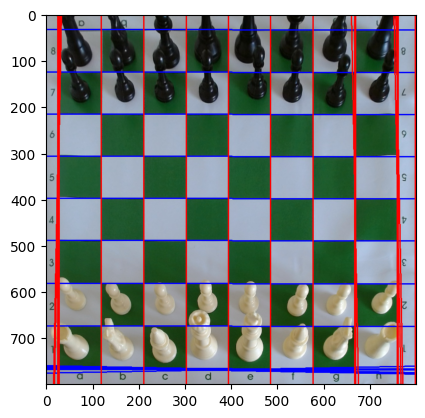

In [19]:
base = board.copy()
for line in h:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (0, 0, 255), 2)
for line in v:
    rho = line[0]
    theta = line[1]
    a = np.cos(theta)
    b = np.sin(theta)
    x0 = a*rho
    y0 = b*rho
    x1 = int(x0 + 1000*(-b))
    y1 = int(y0 + 1000*(a))
    x2 = int(x0 - 1000*(-b))
    y2 = int(y0 - 1000*(a))
    cv2.line(base, (x1, y1), (x2, y2), (255, 0, 0), 2)
plt.imshow(base)

In [20]:
points = []
for rho_h, theta_h in h:
    for rho_v, theta_v in v:
        a = np.array([[np.cos(theta_h), np.sin(theta_h)], [np.cos(theta_v), np.sin(theta_v)]])
        b = np.array([rho_h, rho_v])
        intersect = np.linalg.solve(a, b)
        points.append(intersect)

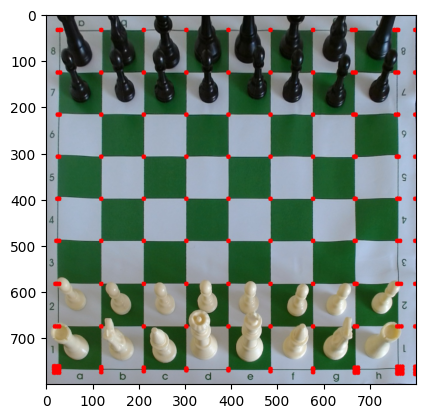

In [21]:
base = board.copy()
for point in points:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [22]:
def cluster_intersections(points, max_dist=55):
    Y = spatial.distance.pdist(points)
    Z = clstr.hierarchy.single(Y)
    T = clstr.hierarchy.fcluster(Z, max_dist, "distance")
    clusters = defaultdict(list)
    for i in range(len(T)):
        clusters[T[i]].append(points[i])
    clusters = clusters.values()
    clusters = map(lambda arr: (np.mean(np.array(arr)[:, 0]), np.mean(np.array(arr)[:, 1])), clusters)
    result = []
    for point in clusters:
        result.append([point[0], point[1]])
    return result
    
points_clustered = cluster_intersections(points)

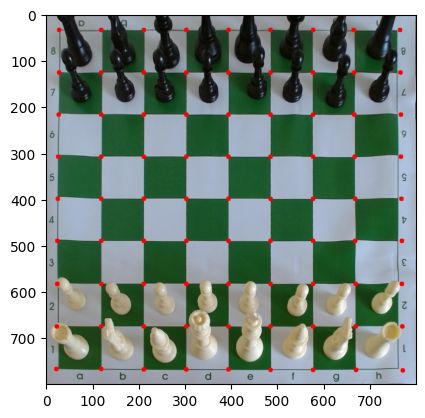

In [23]:
base = board.copy()
for point in points_clustered:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [24]:
len(points_clustered)

81

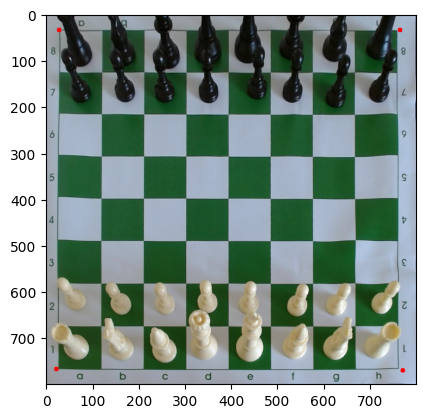

In [25]:
corners = find_corners(points_clustered)
base = board.copy()
for point in corners:
    x, y = point
    cv2.circle(base, (int(x), int(y)), 5, (255, 0, 0), -1)
plt.imshow(base)

In [26]:
h, w = np.max(corners, axis=0)
x_start, y_start = np.min(corners, axis=0)
h, w, x_start, y_start

(np.float32(771.0232),
 np.float32(770.1623),
 np.float32(22.553741),
 np.float32(34.0))

In [27]:
rows = 8
cols = 8

# Create linearly spaced points for the grid edges
x_points = np.linspace(x_start, w, cols + 1, dtype=int)
y_points = np.linspace(y_start, h, rows + 1, dtype=int)

# Create meshgrid to get the X,Y coordinates of all intersections
xv, yv = np.meshgrid(x_points, y_points)

# Extract and print the 4 corners for each grid square
grid_corners = []

for i in range(rows):
    for j in range(cols):
        top_left = (xv[i, j], yv[i, j])
        top_right = (xv[i, j + 1], yv[i, j])
        bottom_left = (xv[i + 1, j], yv[i + 1, j])
        bottom_right = (xv[i + 1, j + 1], yv[i + 1, j])

        
        corners = [top_left, top_right, bottom_left, bottom_right]
        grid_corners.append(corners)

grid_corners = np.array(grid_corners, dtype=np.float32).reshape(-1, 1, 2)
grid_corners = cv2.perspectiveTransform(grid_corners, M_inv)
grid_corners = grid_corners.reshape(-1, 4, 2)

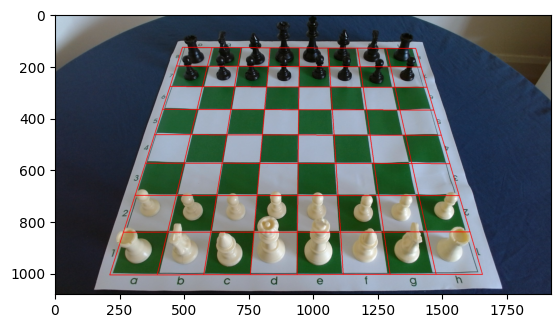

In [28]:
base = img.copy()
for square in grid_corners:
    top_left, top_right, bottom_left, bottom_right = square
    cv2.line(base, (int(top_left[0]), int(top_left[1])), (int(top_right[0]), int(top_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(top_right[0]), int(top_right[1])), (int(bottom_right[0]), int(bottom_right[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_right[0]), int(bottom_right[1])), (int(bottom_left[0]), int(bottom_left[1])), (255, 0, 0), 2)
    cv2.line(base, (int(bottom_left[0]), int(bottom_left[1])), (int(top_left[0]), int(top_left[1])), (255, 0, 0), 2)
plt.imshow(base)

In [29]:
grid_corners[48]

array([[309.79852, 699.9151 ],
       [468.22293, 699.9807 ],
       [264.54108, 841.5372 ],
       [434.05286, 841.4541 ]], dtype=float32)

In [30]:
squares = []
for square in grid_corners:
    x0, y0 = np.min(square, axis=0)
    x1, y1 = np.max(square, axis=0)
    squares.append((x0, y0, x1, y1))
print(squares[48])

(np.float32(264.54108), np.float32(699.9151), np.float32(468.22293), np.float32(841.5372))


In [31]:
squares_dict = {}
cols = "abcdefgh"
rows = "87654321"
square_names = [f'{col}{row}' for row in rows for col in cols]
print(square_names[48])

a2


In [32]:
for square, square_name in zip(squares, square_names):
    squares_dict[square_name] = {'piece': None, 'boundaries': np.array(square), 'score': None}

In [33]:
squares_dict['a2']

{'piece': None,
 'boundaries': array([264.54108, 699.9151 , 468.22293, 841.5372 ], dtype=float32),
 'score': None}

np.True_

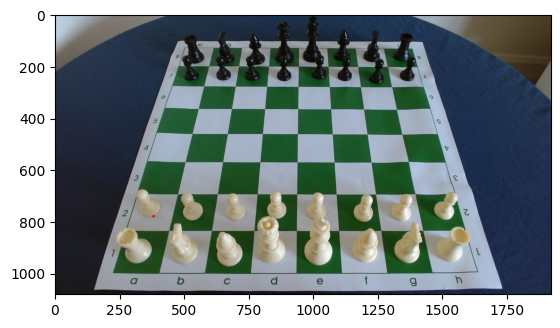

In [34]:
t = (380, 780)
base = img.copy()
cv2.circle(base, (int(t[0]), int(t[1])), 5, (255, 0, 0), -1)
plt.imshow(base)
squares_dict['a2']['boundaries'][0] < t[0] <= squares_dict['a2']['boundaries'][2] and squares_dict['a2']['boundaries'][1] < t[1] <= squares_dict['a2']['boundaries'][3]

In [35]:
squares_dict

{'a8': {'piece': None,
  'boundaries': array([469.32318, 128.95851, 606.0303 , 201.15228], dtype=float32),
  'score': None},
 'b8': {'piece': None,
  'boundaries': array([588.705  , 129.42097, 718.4312 , 201.57748], dtype=float32),
  'score': None},
 'c8': {'piece': None,
  'boundaries': array([706.6377 , 129.87787, 830.67065, 202.00204], dtype=float32),
  'score': None},
 'd8': {'piece': None,
  'boundaries': array([824.3925 , 130.33409, 943.9531 , 202.43053], dtype=float32),
  'score': None},
 'e8': {'piece': None,
  'boundaries': array([ 943.2333 ,  130.79457, 1060.6318 ,  202.8538 ], dtype=float32),
  'score': None},
 'f8': {'piece': None,
  'boundaries': array([1055.8688 ,  131.24948, 1179.1133 ,  203.28099], dtype=float32),
  'score': None},
 'g8': {'piece': None,
  'boundaries': array([1168.8247 ,  131.70862, 1296.1571 ,  203.70299], dtype=float32),
  'score': None},
 'h8': {'piece': None,
  'boundaries': array([1280.418  ,  132.16223, 1414.2809 ,  204.12888], dtype=float32),
  